### PH464/564: Scientific Computing II
***J.S. Hazboun***

___

# Homework 1
### Due: Friday, Oct 3rd at 11:59pm Pacific
---

## Handing in Homework

You had the opportunity to practice your git and GitHub skills by submitting HW0 via GitHub. You will need to repeat the process for every homework assigment going forward. Please make sure a copy of the completed assignment is placed in your repos "my_work" directory and pushed to GitHub. Please label files _starting_ with the appropriate hw number. This week's will be `hw1_YOUR_NAME.ipynb`. In addition, I want another document which only has the answers to the questions asked in this HW assignment, along with any figures that you deem appropriate to make yourself understood. Please restate the question where appropriate. Code files will be checked for completeness **only**. I will only consider the answers in the separate `pdf` for grading your understanding of the questions.

**WARNING for devcontainer users:** If you are using the **devcontainer** via `VSCode`, then you will want to make a separate working folder directly in your fork of the class repo and work on your assignment by either _copying_ a notebook in there or opening a new one in that folder. The reason is that the _repo_ has the devcontainer instructions and when you open `VSCode` it recognizes this and starts up the devcontainer.  

## Problem 1



Consider a family with two children. Assume that the probability of females and males being born is equal, i.e. $p(F)=0.5$ and $p(M)=0.5$. Remember that "given" means your calculation is conditioned on some already fixed data or outcome. 

1) What is the probability of one male and one female **GIVEN** that the first child is male. 

2) What is the probability of two females **GIVEN** that at least one child is female.

3) What is the probability of two females **GIVEN** that the older child is female.

You will find it easiest to answer these questions by sketching a "tree diagram" to visualize the options for the oldest child, and the branching options for the youngest child. 

Either write your solution as Markdown/Latex below, or paste in a scanned image of your handwritten solution.

### Solution

1) *(To get you started)* If the first child is male, then the only unknown is the sex of the second child. We want the second child to be female, which has a probability of 0.5. Thus, $p(F,M |C_1=M) = 0.5$. 

2) p = 1/3 of two females given that one child is female.

3) p = 0.5 of two females given that the older child is female.

## Problem 2

1) Use `numpy` to draw $1000$ random samples from a uniform distribution between $0.1$ and $10$, and store these samples as $x$.

2) Use matplotlib to make a histogram of these samples. Try to make this as aesthetically pleasing as possible (within reason).

3) Compute the base-10 log of your array $x$, and store this as $y$.

4) Make another histogram for $y$. Using the equation to transform probability distributions in `Lecture_2`, write here what the theoretical pdf of $y$ is, and overplot it onto your histogram.

5) Compute the mean of $x$ and the mean of $y$. Now compute the median of $x$ and the median of $y$. You should note that the means are different, but the medians (as it is a cumulative statistic) are the same. The mean is affected by the scale of the sample values, but the median only depends on the ordering of the samples. Monotonic transformations (like taking the log) do not change the ordering of samples.

### Solution

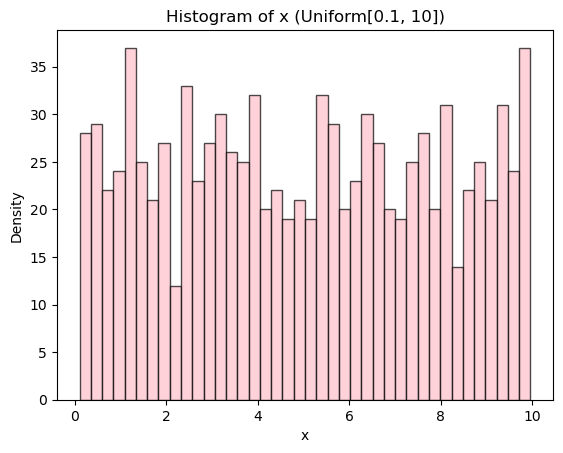

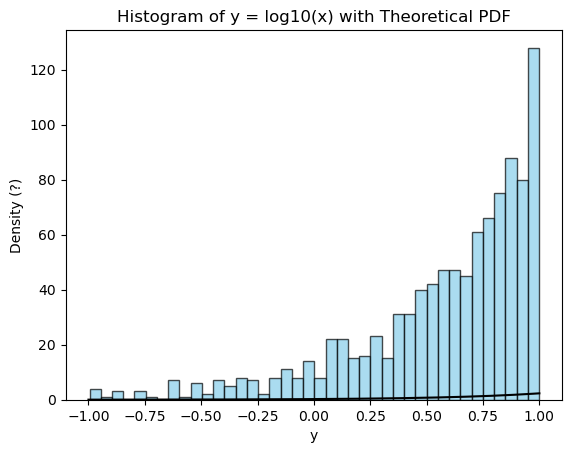

mean(x)   = 5.000547660313968
mean(y)   = 0.5745958933272884
median(x) = 4.992607048559201
median(y) = 0.698327306043143


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Part 1
x = np.random.uniform(0.1, 10, 1000)
#print(x[:10])

# Part 2
plt.hist(x, bins=40, color='pink', edgecolor='k', alpha=0.7)
plt.title("Histogram of x (Uniform[0.1, 10])")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

# Part 3
y = np.log10(x)

# Part 4
plt.hist(y, bins=40, color='skyblue', edgecolor='k', alpha=0.7)
y_grid = np.linspace(-1, 1, 500)
p_y = (np.log(10) / 9.9) * 10**y_grid
plt.plot(y_grid, p_y, '-k')
plt.title("Histogram of y = log10(x) with Theoretical PDF")
plt.xlabel("y")
plt.ylabel("Density (?)")
plt.show()

# Part 5
mean_x = np.mean(x)
mean_y = np.mean(y)
median_x = np.median(x)
median_y = np.median(y)

print("mean(x)   =", mean_x)
print("mean(y)   =", mean_y)
print("median(x) =", median_x)
print("median(y) =", median_y)

## Problem 3

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. 

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian Python object from part (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

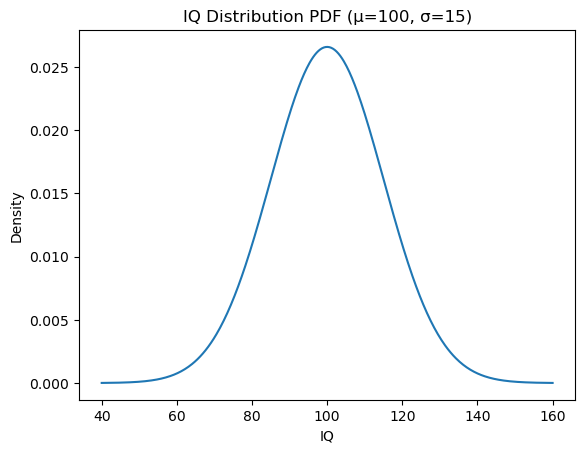

10 random IQ samples: [107.57568862  90.95916787  99.17990448  87.05832206  88.20501387
 101.86867784  99.43343655  90.82397298  94.42682285 110.08903565]
PDF at IQ=145: 0.0002954565607958672


In [19]:
from scipy import stats

# Part 1

mu = 100
sigma = 15

iq_dist = stats.norm(loc=mu, scale=sigma)

x_grid = np.linspace(40, 160, 500)
pdf_vals = iq_dist.pdf(x_grid)

plt.plot(x_grid, pdf_vals)
plt.title("IQ Distribution PDF (μ=100, σ=15)")
plt.xlabel("IQ")
plt.ylabel("Density")
plt.show()

samples = iq_dist.rvs(10)
print("10 random IQ samples:", samples)

pdf_at_145 = iq_dist.pdf(145)
print("PDF at IQ=145:", pdf_at_145)

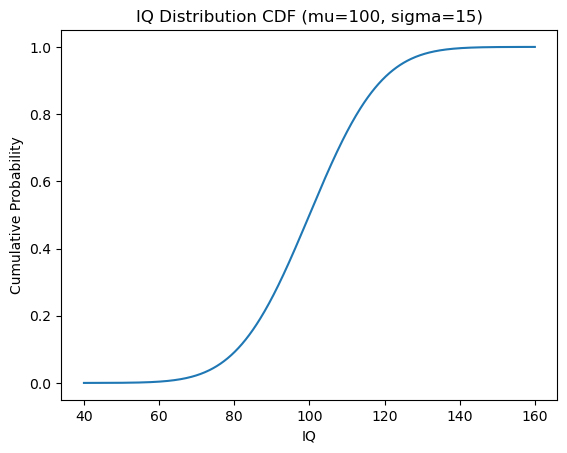

In [20]:
# Part 2

cdf_vals = iq_dist.cdf(x_grid)
plt.plot(x_grid, cdf_vals)
plt.title("IQ Distribution CDF (mu=100, sigma=15)")
plt.xlabel("IQ")
plt.ylabel("Cumulative Probability")
plt.show()

In [21]:
# Part 3

fraction_above_145 = 1 - iq_dist.cdf(145)
print("Fraction of people with IQ > 145:", fraction_above_145)

Fraction of people with IQ > 145: 0.0013498980316301035


In [22]:
# Part 4

one_in_a_million_iq = iq_dist.ppf(1 - 1e-6)
print("IQ for one in a million:", one_in_a_million_iq)

IQ for one in a million: 171.3013646322563
